<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_06/avcad_ex06_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 6**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `How do I run a bivariate isolation forest with sklearn and plot the contour of anomaly scores?`
- `What's the difference between log and sqrt transformations for skewed positive data?`
- `How do I use lmplot with hue to show regression lines per group in a single plot?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

Using the dataset in `EFIplus_medit.zip`:

1. Check visually if any of the continuous environmental variables in the EFIplus_medit dataset (Altitude, Actual_river_slope, Elevation_mean_catch, prec_ann_catch, temp_ann, temp_jan, temp_jul) would require a data transformation in order to apply parametric tests.
2. Apply the appropriate data transformation and check the new distributions.
3. Create a column with the total number of species present (the species richness) in each sampling site (NOTE: the first species in the dataset is *Abramis brama* and all the columns to the right correspond to species presence/absence).
4. Check the existence of bivariate outliers in the relationship between Mean Annual Temperature ('temp_ann') and species richness using an appropriate plot. Run a bivariate isolation forest to detect outliers and plot the result.
5. Explore visually, using a single plot, if this relationship (temp_ann x species richness) may vary across countries.

## 1. Setup and Data Preparation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest

In [2]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with NaN
df2 = df.dropna().copy()
print(f"Shape after dropna: {df2.shape}")

Shape after dropna: (2822, 154)


In [3]:
# @title Global Plot Settings

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

---
## 2. Q1: Visually check whether continuous environmental variables require data transformation

Parametric tests (t-test, ANOVA, Pearson correlation, etc.) assume that the data is approximately normally distributed. Variables that are strongly skewed will violate this assumption and may require a transformation.

We inspect each variable using:
- **Histograms with KDE** — to see the shape of the distribution
- **QQ-plots** — to compare quantiles of the data to those of a normal distribution
- **Skewness** — a numerical summary (|skew| > 1 → strongly skewed)

In [4]:
env_vars = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
            'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

# Summary statistics including skewness
summary = pd.DataFrame({
    'mean':  df2[env_vars].mean().round(2),
    'median': df2[env_vars].median().round(2),
    'std':   df2[env_vars].std().round(2),
    'min':   df2[env_vars].min().round(2),
    'max':   df2[env_vars].max().round(2),
    'skew':  df2[env_vars].skew().round(3),
})
summary

,mean,median,std,min,max,skew
Altitude,344.70,292.00,291.16,1.00,1440.00,0.954
Actual_river_slope,15.36,8.80,24.16,0.00,774.00,12.757
Elevation_mean_catch,668.77,590.00,371.26,52.25,2003.13,0.754
prec_ann_catch,1069.98,1074.66,250.83,456.28,1739.00,-0.259
temp_ann,13.43,13.50,1.91,6.70,17.50,-0.213
temp_jan,7.04,7.30,2.44,-0.20,11.90,-0.403
temp_jul,19.92,19.50,2.02,14.70,25.70,0.638


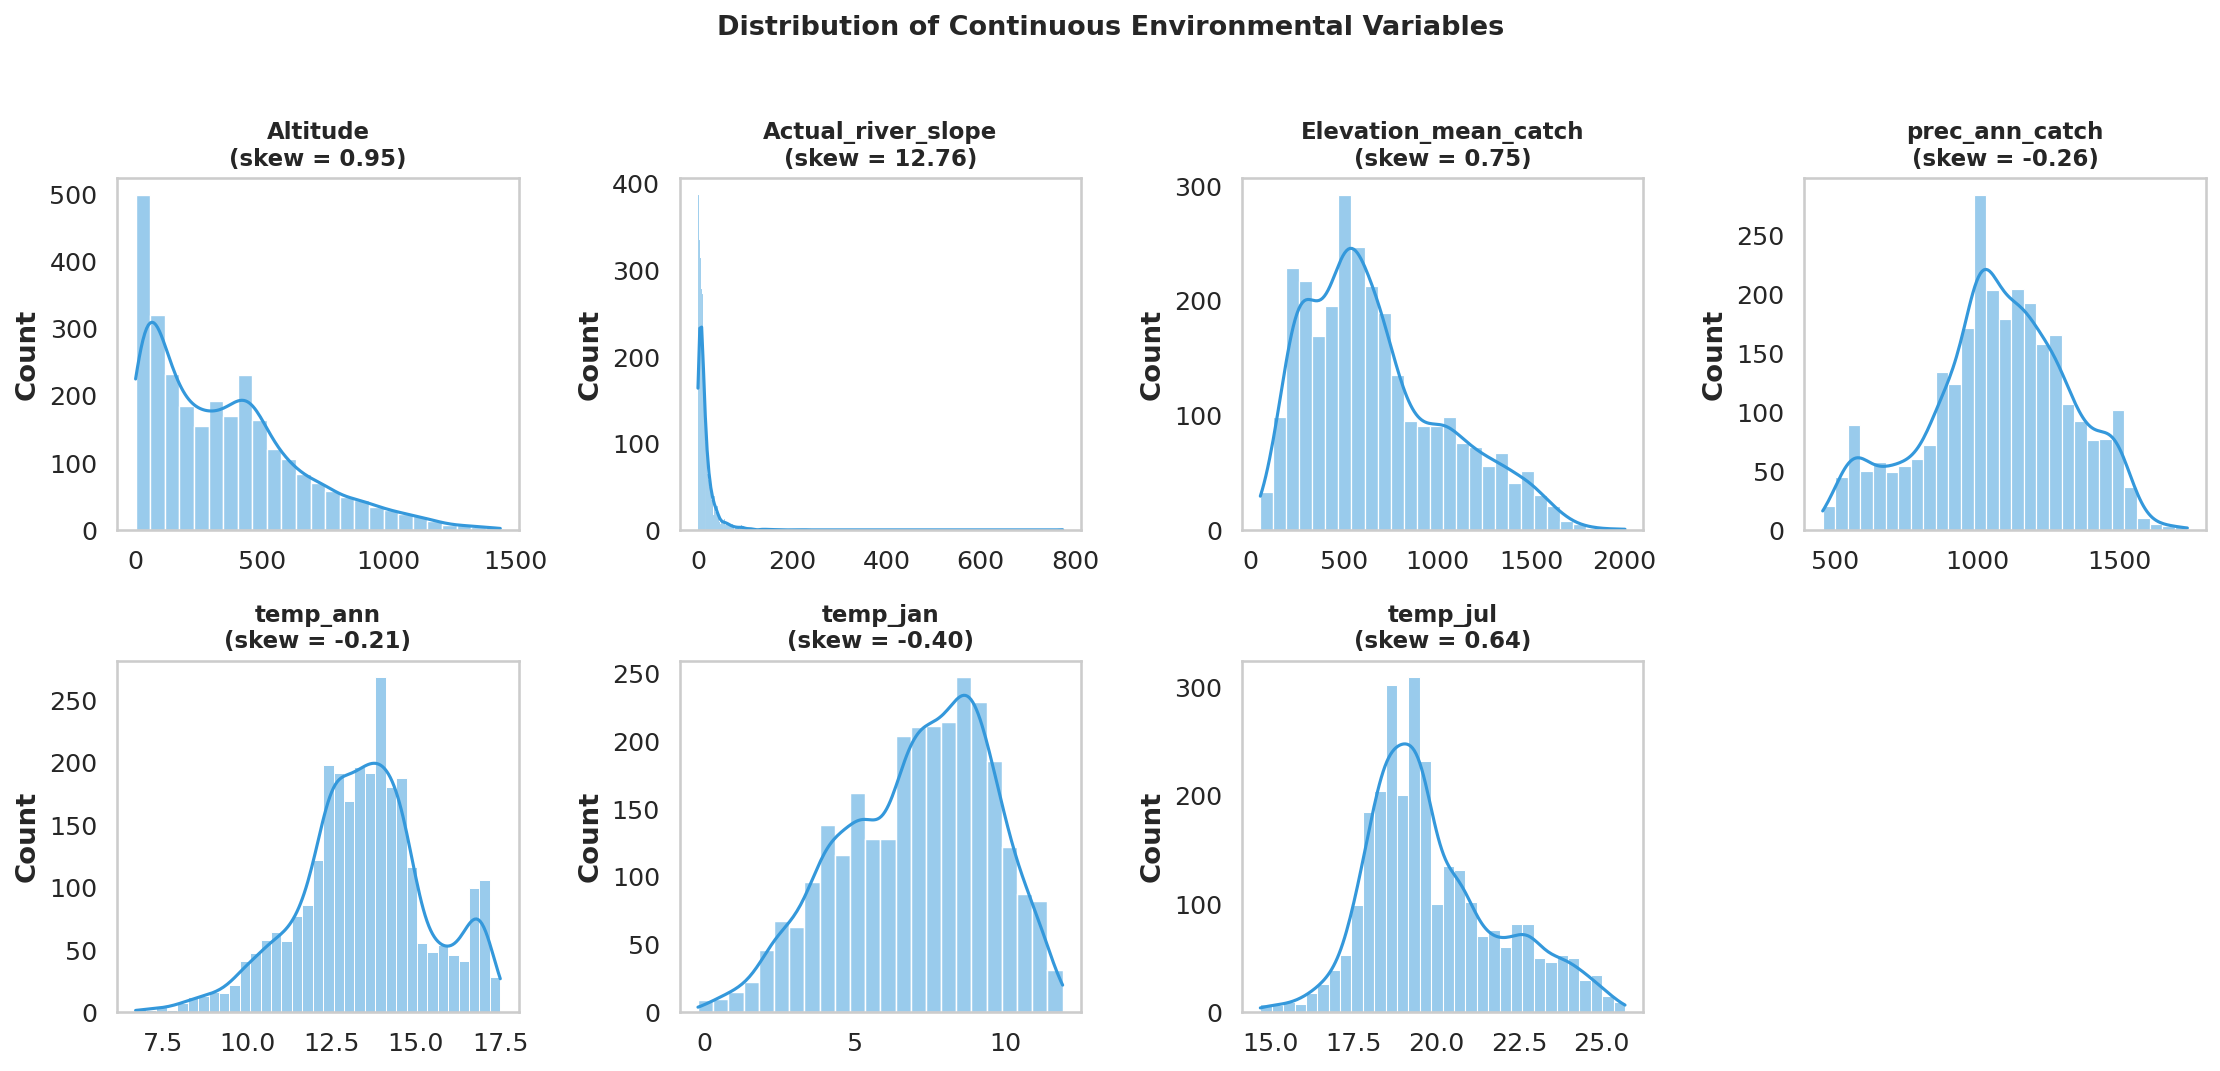

In [5]:
# @title Histograms of the seven environmental variables

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, var in enumerate(env_vars):
    sns.histplot(df2[var], kde=True, ax=axes[i], color='#3498db', edgecolor='white')
    axes[i].set_title(f"{var}\n(skew = {df2[var].skew():.2f})", fontsize=11)
    axes[i].set_xlabel("")
    axes[i].grid(False)

axes[-1].axis('off')
fig.suptitle("Distribution of Continuous Environmental Variables",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

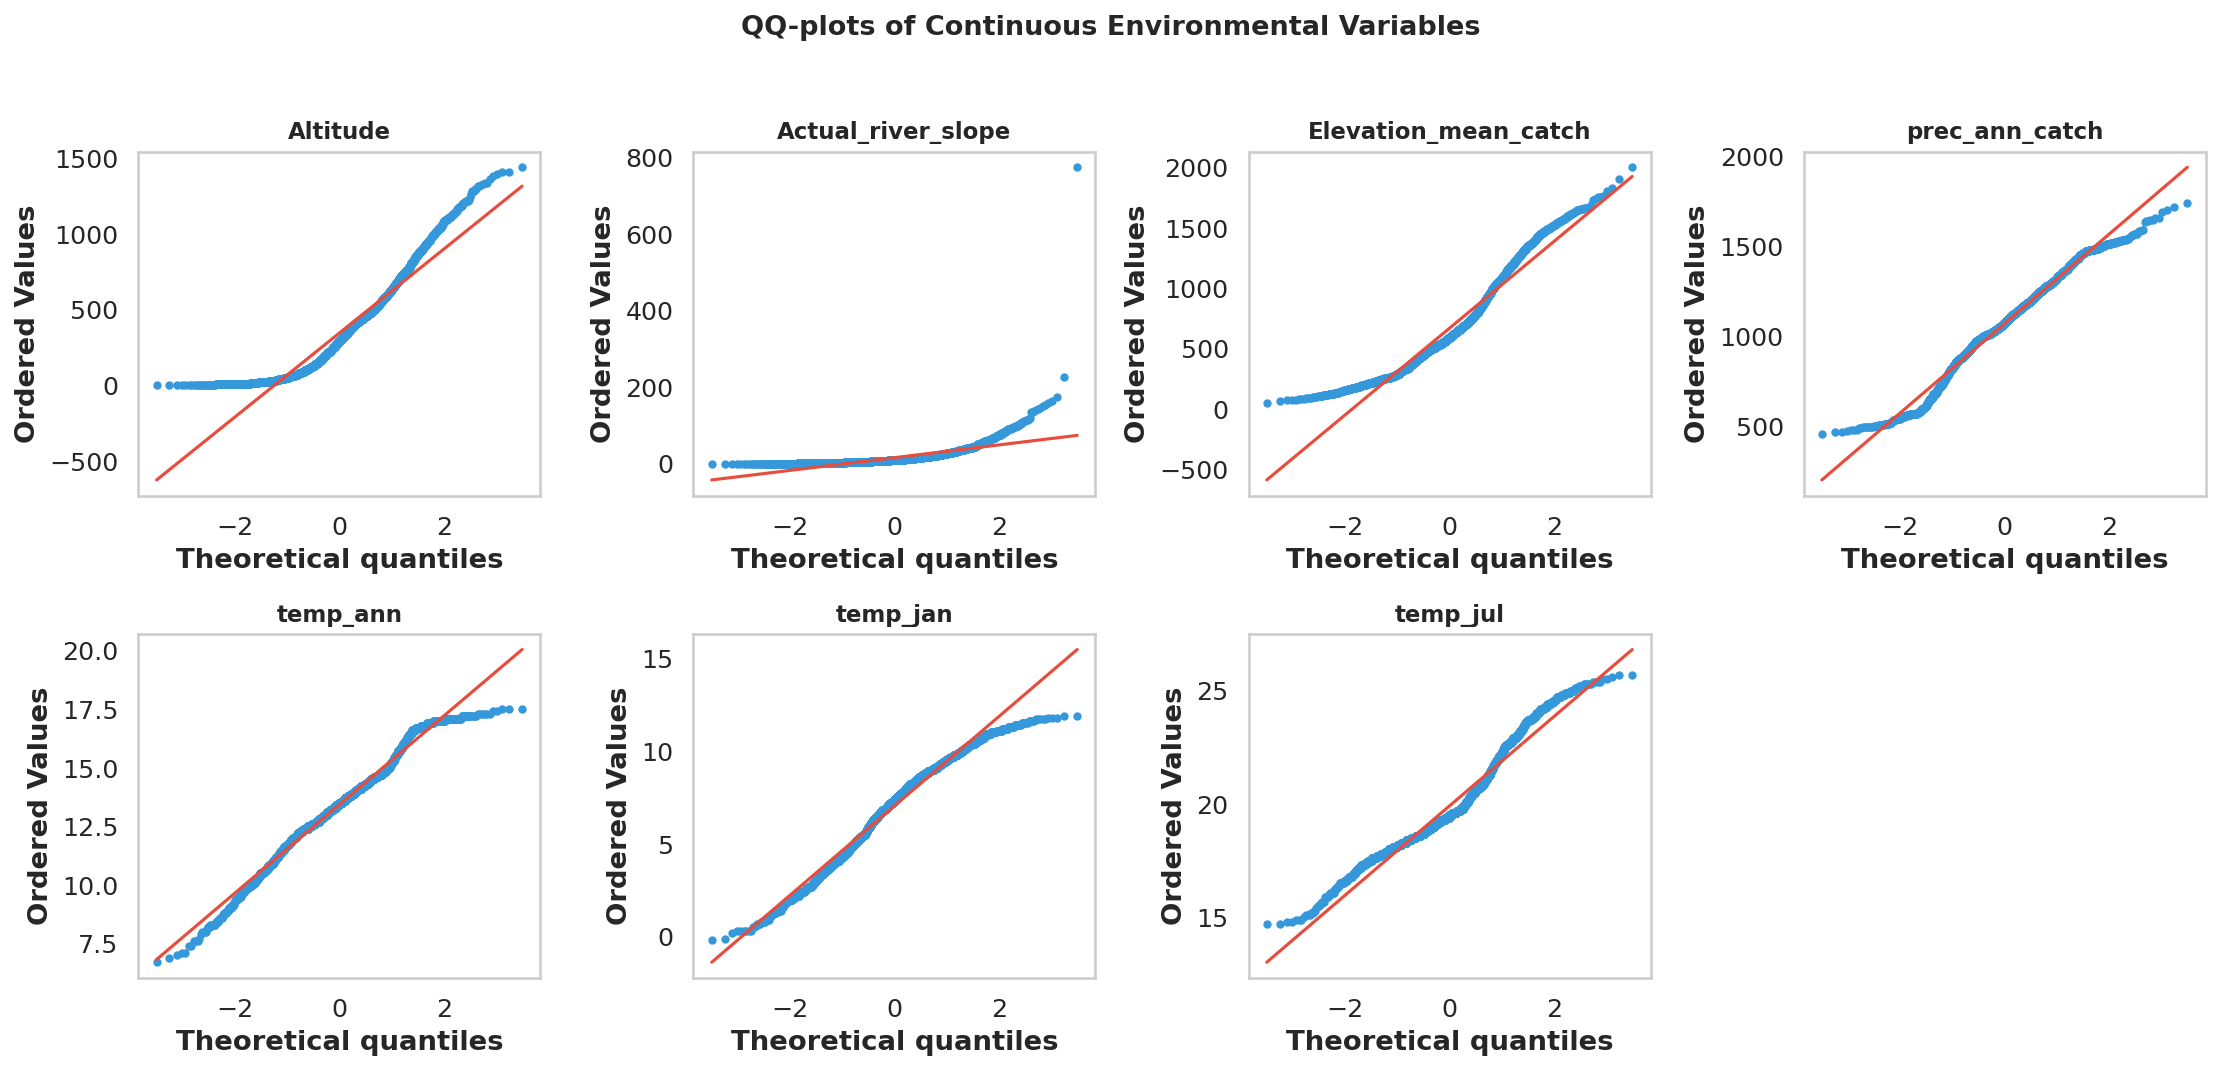

In [6]:
# @title QQ-plots to check normality

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, var in enumerate(env_vars):
    stats.probplot(df2[var], dist="norm", plot=axes[i])
    axes[i].set_title(var, fontsize=11)
    axes[i].get_lines()[0].set_markerfacecolor('#3498db')
    axes[i].get_lines()[0].set_markeredgecolor('#3498db')
    axes[i].get_lines()[0].set_markersize(3)
    axes[i].get_lines()[1].set_color('#e74c3c')
    axes[i].grid(False)

axes[-1].axis('off')
fig.suptitle("QQ-plots of Continuous Environmental Variables",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Looking at both the histograms and QQ-plots, the variables that clearly **deviate from normality** are:

- **Altitude** — strong right skew (skew ≈ 1)
- **Actual_river_slope** — very strong right skew (skew >> 1), heavy tail of high values
- **prec_ann_catch** — moderate right skew

The temperature variables (`temp_ann`, `temp_jan`, `temp_jul`) and `Elevation_mean_catch` look approximately symmetric in the histograms and follow the diagonal in the QQ-plots reasonably well, so they don't require transformation.

Right-skewed positive variables are typical candidates for a **log transformation** (or square-root for milder skew).

---
## 3. Q2: Apply the appropriate data transformation and check the new distributions

We apply a `log1p` (i.e. log(1+x)) transformation to the three skewed variables. `log1p` is preferred over `log` because some values can be 0 (e.g., zero river slope), which would yield -∞.

In [7]:
skewed_vars = ['Altitude', 'Actual_river_slope', 'prec_ann_catch']

for var in skewed_vars:
    df2[f'{var}_log'] = np.log1p(df2[var])

# Compare skewness before/after
comparison = pd.DataFrame({
    'skew_original':    [df2[v].skew() for v in skewed_vars],
    'skew_transformed': [df2[f'{v}_log'].skew() for v in skewed_vars],
}, index=skewed_vars).round(3)
comparison

,skew_original,skew_transformed
Altitude,0.954,-0.958
Actual_river_slope,12.757,0.012
prec_ann_catch,-0.259,-0.890


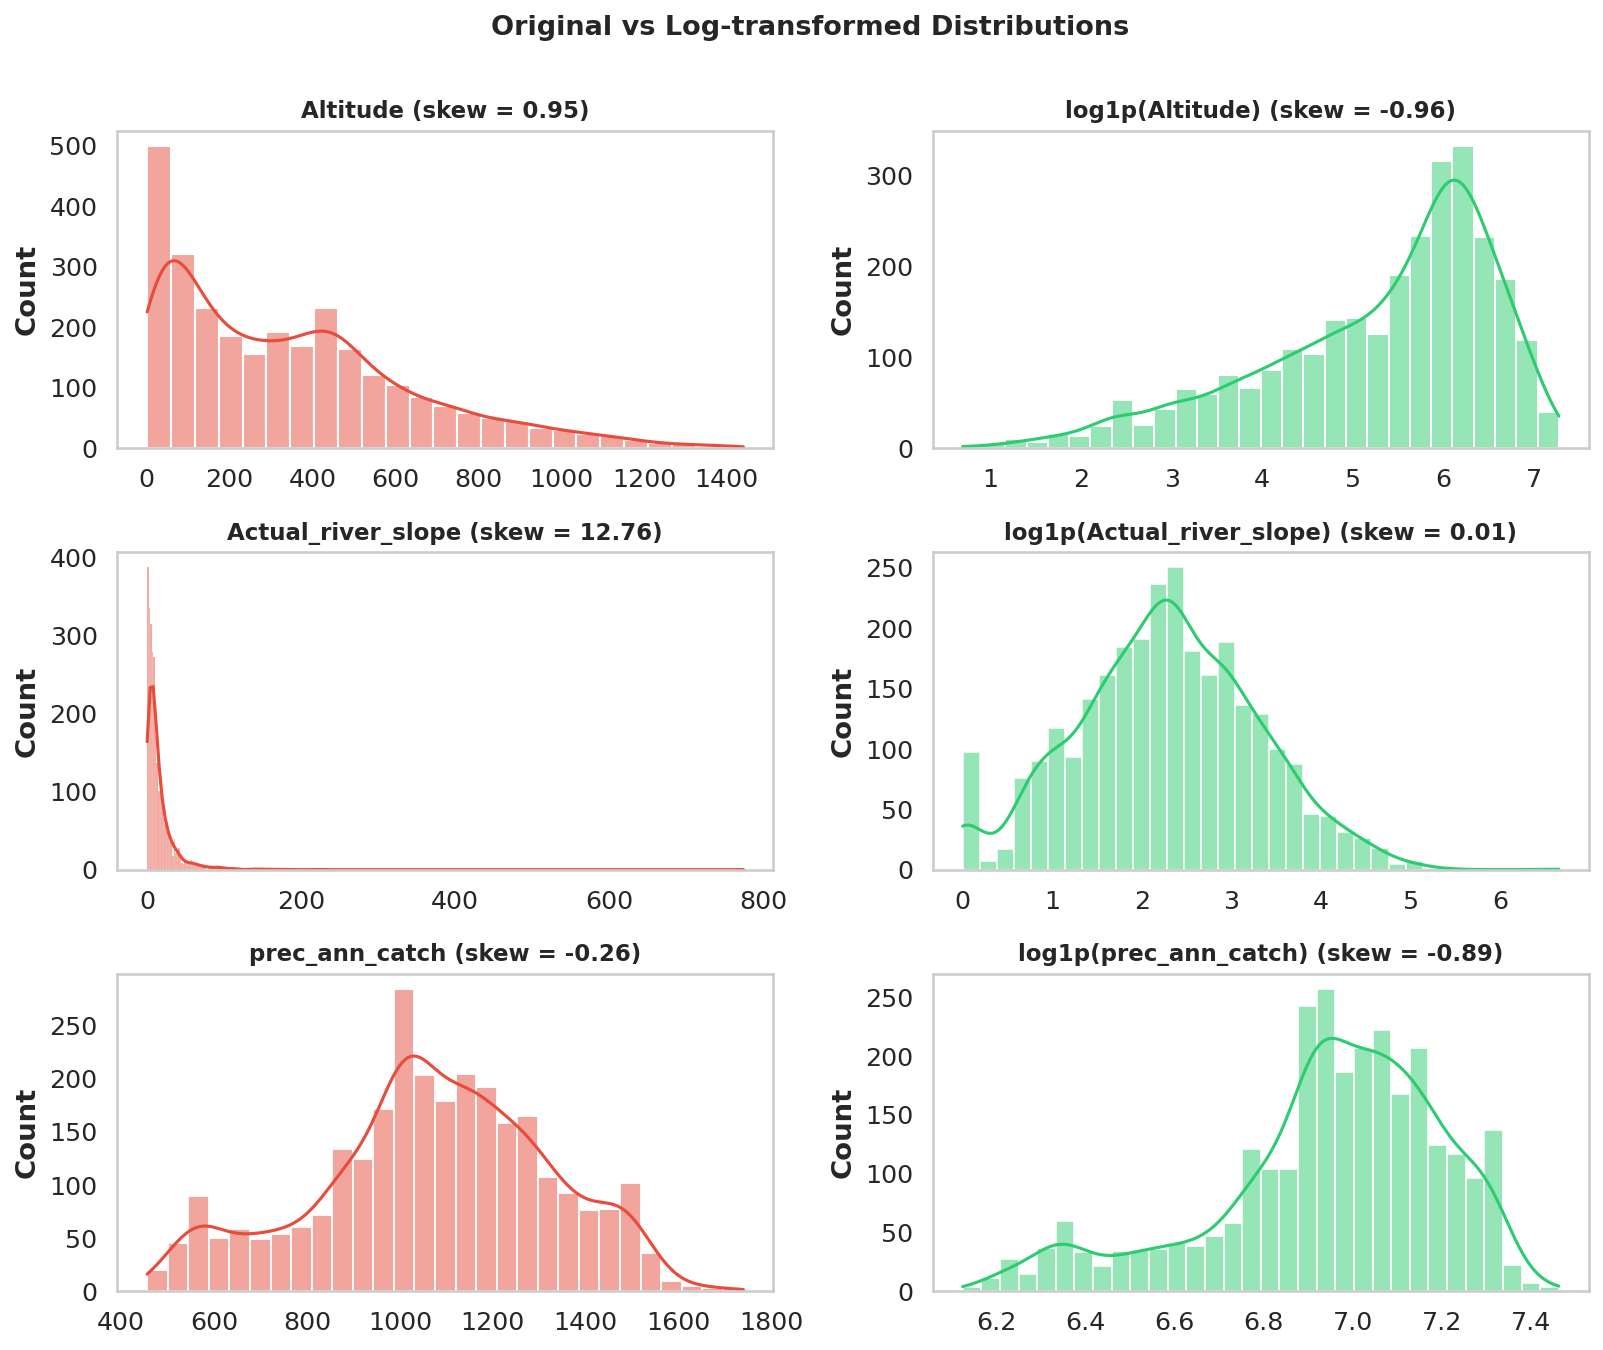

In [8]:
# @title Histograms — original vs log-transformed

fig, axes = plt.subplots(3, 2, figsize=(11, 9))

for i, var in enumerate(skewed_vars):
    # Original
    sns.histplot(df2[var], kde=True, ax=axes[i, 0], color='#e74c3c', edgecolor='white')
    axes[i, 0].set_title(f"{var} (skew = {df2[var].skew():.2f})", fontsize=11)
    axes[i, 0].set_xlabel("")
    axes[i, 0].grid(False)

    # Log-transformed
    sns.histplot(df2[f'{var}_log'], kde=True, ax=axes[i, 1], color='#2ecc71', edgecolor='white')
    axes[i, 1].set_title(f"log1p({var}) (skew = {df2[f'{var}_log'].skew():.2f})", fontsize=11)
    axes[i, 1].set_xlabel("")
    axes[i, 1].grid(False)

fig.suptitle("Original vs Log-transformed Distributions",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

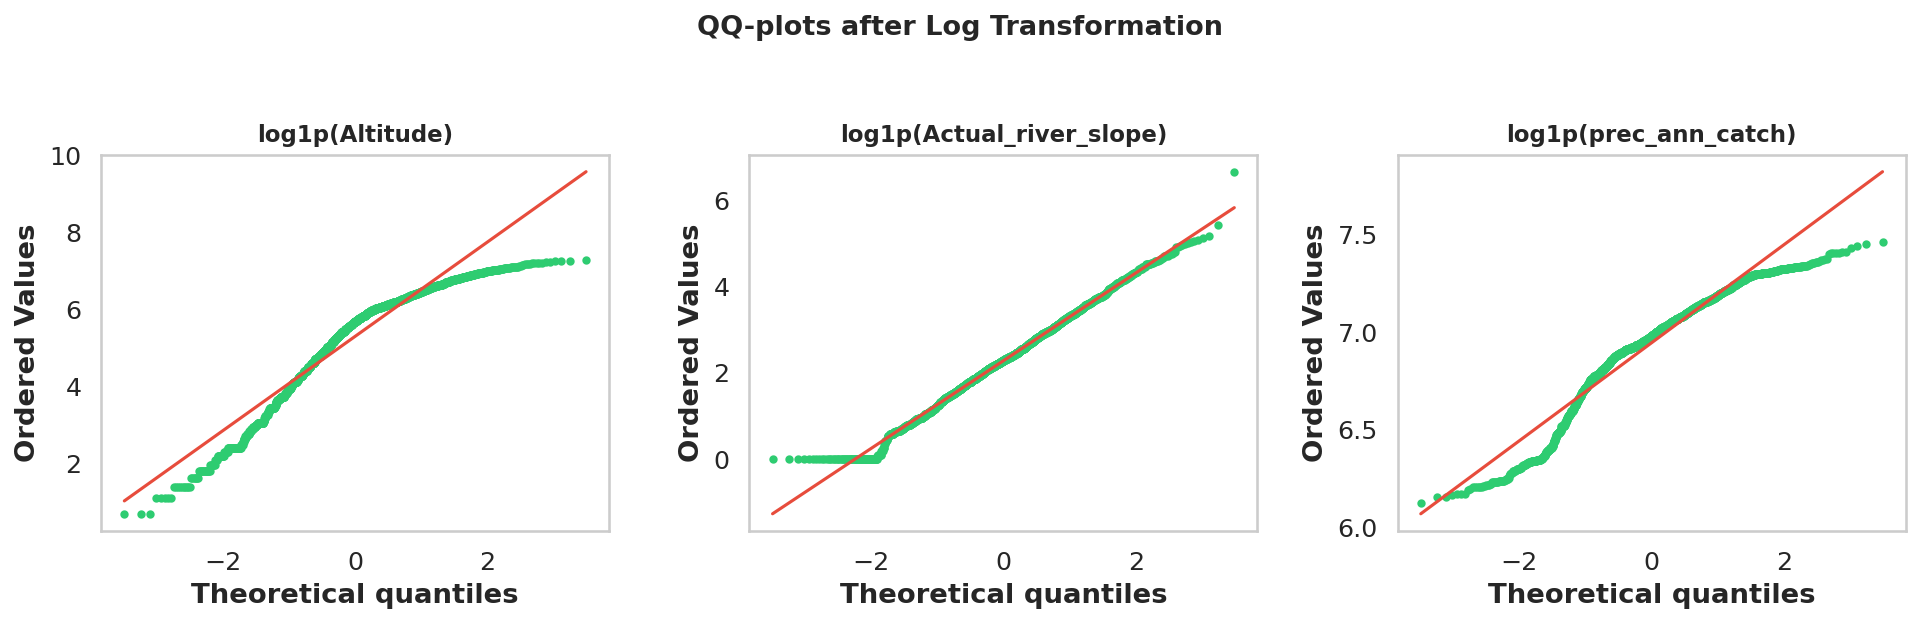

In [9]:
# @title QQ-plots after transformation

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for i, var in enumerate(skewed_vars):
    stats.probplot(df2[f'{var}_log'], dist="norm", plot=axes[i])
    axes[i].set_title(f"log1p({var})", fontsize=11)
    axes[i].get_lines()[0].set_markerfacecolor('#2ecc71')
    axes[i].get_lines()[0].set_markeredgecolor('#2ecc71')
    axes[i].get_lines()[0].set_markersize(3)
    axes[i].get_lines()[1].set_color('#e74c3c')
    axes[i].grid(False)

fig.suptitle("QQ-plots after Log Transformation",
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

After applying the `log1p` transformation, the skewness drops substantially toward 0 for all three variables, and the QQ-plot points align more closely with the diagonal red line. The transformed variables are now much closer to a normal distribution and are suitable for parametric tests. `Actual_river_slope`, which was the most skewed, also benefits the most — although it still has a slight tail, it is far more symmetric than the original.

---
## 4. Q3: Create a species richness column

Species richness = the total number of species present at a sampling site. We sum the binary presence/absence columns starting from *Abramis brama* to the last column.

In [10]:
# Locate the column index of 'Abramis brama' (the first species column)
first_species_idx = df2.columns.get_loc('Abramis brama')
print(f"'Abramis brama' is at column index: {first_species_idx}")
print(f"Number of species columns: {df2.shape[1] - first_species_idx - 3}  (excluding the 3 helper columns we just added)")

# Take only the original species columns (exclude the *_log helpers)
species_cols = [c for c in df2.columns[first_species_idx:] if not c.endswith('_log')]

# Compute species richness
df2['species_richness'] = df2[species_cols].sum(axis=1)

print(f"\nSpecies richness summary:")
print(df2['species_richness'].describe().round(2))

'Abramis brama' is at column index: 46
Number of species columns: 108  (excluding the 3 helper columns we just added)

Species richness summary:
count    2822.00
mean        3.42
std         2.43
min         0.00
25%         1.00
50%         3.00
75%         5.00
max        14.00
Name: species_richness, dtype: float64


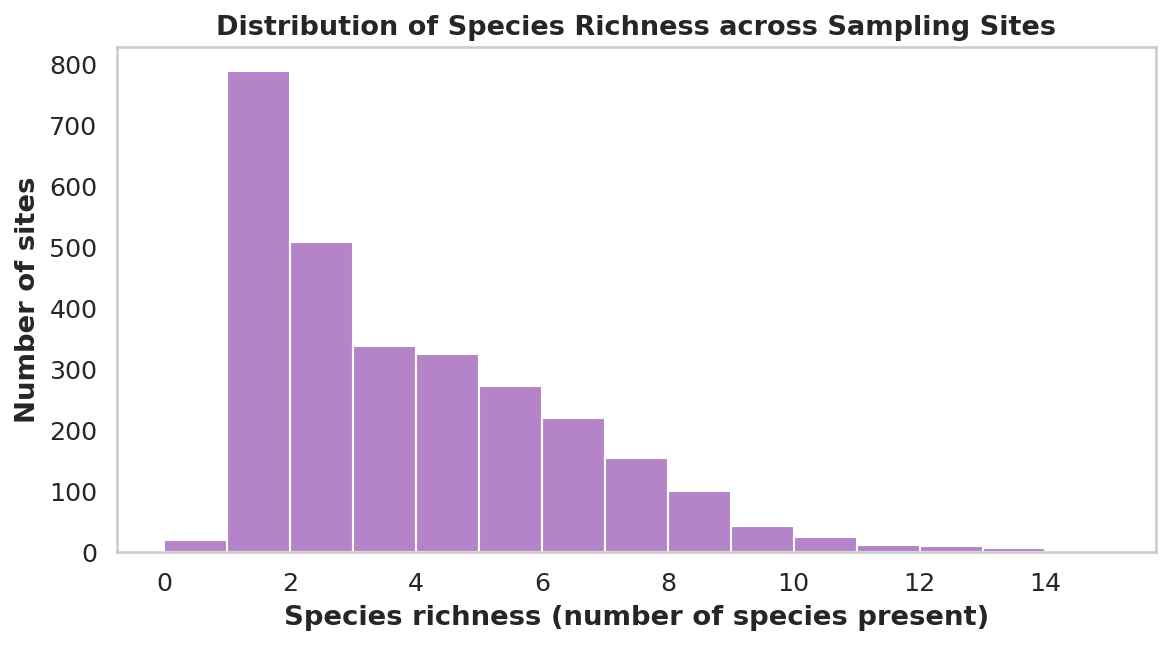

In [11]:
# @title Distribution of species richness

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df2['species_richness'], bins=range(0, int(df2['species_richness'].max())+2),
             color='#9b59b6', edgecolor='white', ax=ax)
ax.set_title("Distribution of Species Richness across Sampling Sites",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Species richness (number of species present)")
ax.set_ylabel("Number of sites")
ax.grid(False)
plt.tight_layout()
plt.show()

---
## 5. Q4: Bivariate outliers — temp_ann × species_richness

We first inspect the bivariate relationship visually with a scatterplot. Then we use a **bivariate Isolation Forest** (`sklearn.ensemble.IsolationForest`) to flag observations that are isolated in the 2D space — these are the candidate outliers.

Isolation Forest works by repeatedly partitioning the data with random splits; points that are isolated quickly (in few splits) are considered anomalies.

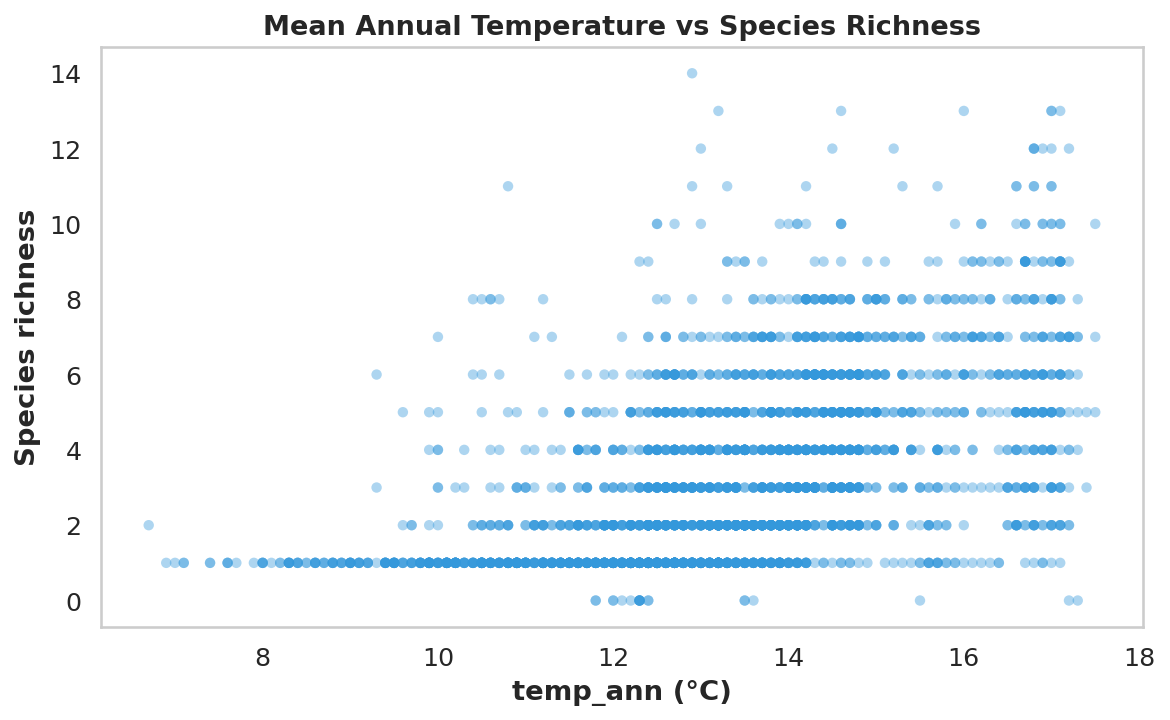

In [12]:
# @title Scatter — temp_ann vs species richness

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='temp_ann', y='species_richness', data=df2,
                ax=ax, alpha=0.4, s=25, color='#3498db', edgecolor='none')
ax.set_title("Mean Annual Temperature vs Species Richness",
             fontsize=13, fontweight='bold')
ax.set_xlabel("temp_ann (°C)")
ax.set_ylabel("Species richness")
ax.grid(False)
plt.tight_layout()
plt.show()

In [13]:
# @title Bivariate Isolation Forest

X = df2[['temp_ann', 'species_richness']].values

iso = IsolationForest(contamination=0.05, random_state=42)
df2['outlier_iso'] = iso.fit_predict(X)  # -1 = outlier, 1 = inlier
df2['outlier_label'] = df2['outlier_iso'].map({1: 'Inlier', -1: 'Outlier'})

n_out = (df2['outlier_iso'] == -1).sum()
print(f"Outliers detected: {n_out} / {len(df2)} ({n_out/len(df2)*100:.1f}%)")

Outliers detected: 140 / 2822 (5.0%)


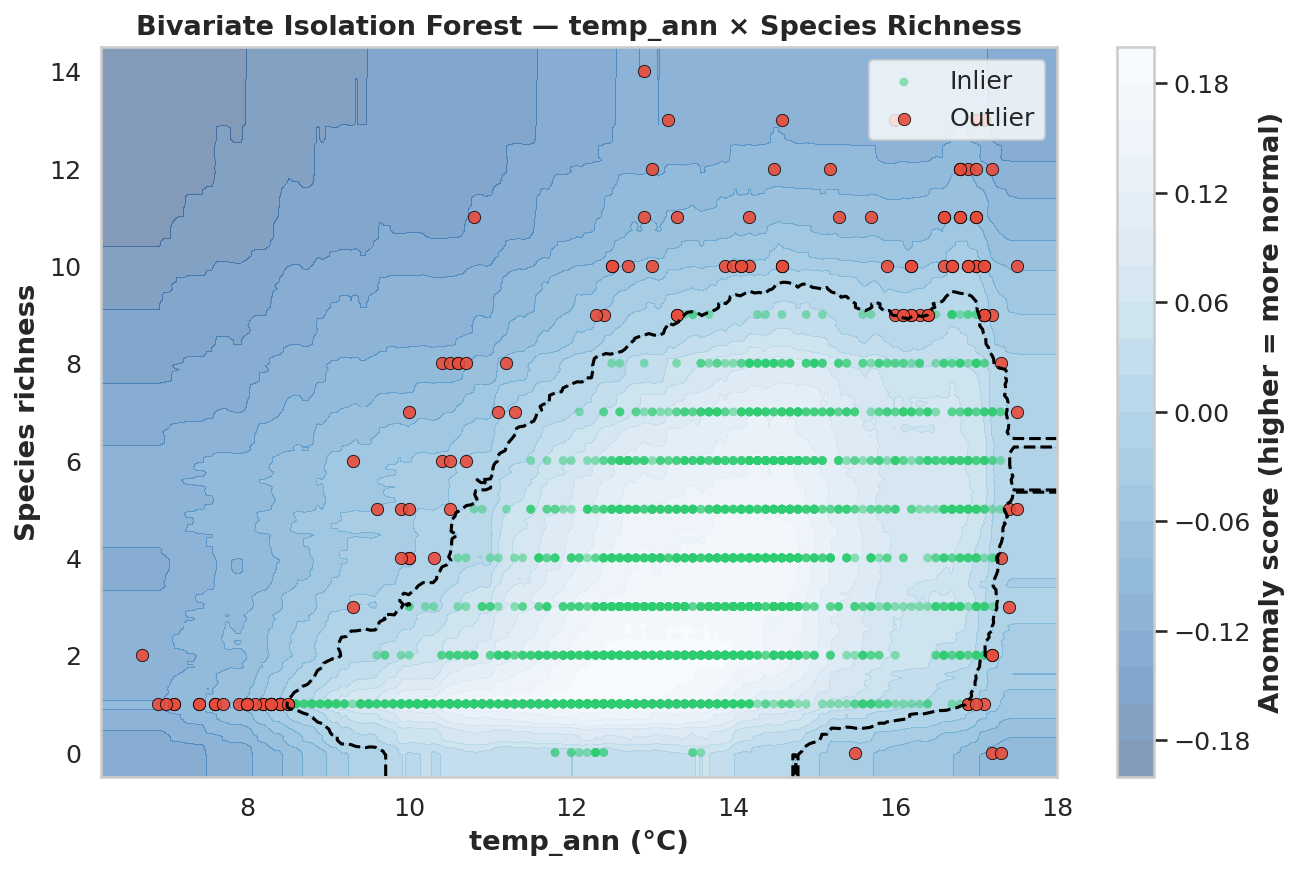

In [14]:
# @title Plot the Isolation Forest result

# Build a grid for the anomaly score contour
xx, yy = np.meshgrid(
    np.linspace(df2['temp_ann'].min()-0.5, df2['temp_ann'].max()+0.5, 200),
    np.linspace(df2['species_richness'].min()-0.5, df2['species_richness'].max()+0.5, 200),
)
Z = iso.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))

# Anomaly score background
cf = ax.contourf(xx, yy, Z, levels=20, cmap='Blues_r', alpha=0.5)
ax.contour(xx, yy, Z, levels=[0], linewidths=1.5, colors='black', linestyles='--')

# Inliers and outliers
inliers  = df2[df2['outlier_iso'] == 1]
outliers = df2[df2['outlier_iso'] == -1]
ax.scatter(inliers['temp_ann'], inliers['species_richness'],
           s=18, c='#2ecc71', alpha=0.5, edgecolor='none', label='Inlier')
ax.scatter(outliers['temp_ann'], outliers['species_richness'],
           s=35, c='#e74c3c', alpha=0.9, edgecolor='black', linewidth=0.4,
           label='Outlier')

ax.set_title("Bivariate Isolation Forest — temp_ann × Species Richness",
             fontsize=13, fontweight='bold')
ax.set_xlabel("temp_ann (°C)")
ax.set_ylabel("Species richness")
ax.legend(loc='upper right')
ax.grid(False)
plt.colorbar(cf, ax=ax, label='Anomaly score (higher = more normal)')
plt.tight_layout()
plt.show()

The Isolation Forest, with a contamination rate of 5%, flags points that fall in the low-density edges of the joint distribution: very high species richness combined with low/intermediate temperatures, and the rare points at the extremes of `temp_ann`. The dashed line marks the decision boundary between inliers and outliers, and the colored background represents the anomaly score (lighter = more anomalous).

---
## 6. Q5: Does the relationship temp_ann × species_richness vary across countries?

We use a single `lmplot` with `hue='Country'` to overlay one regression line per country on the same scatter. This makes it easy to compare slopes and intercepts visually.

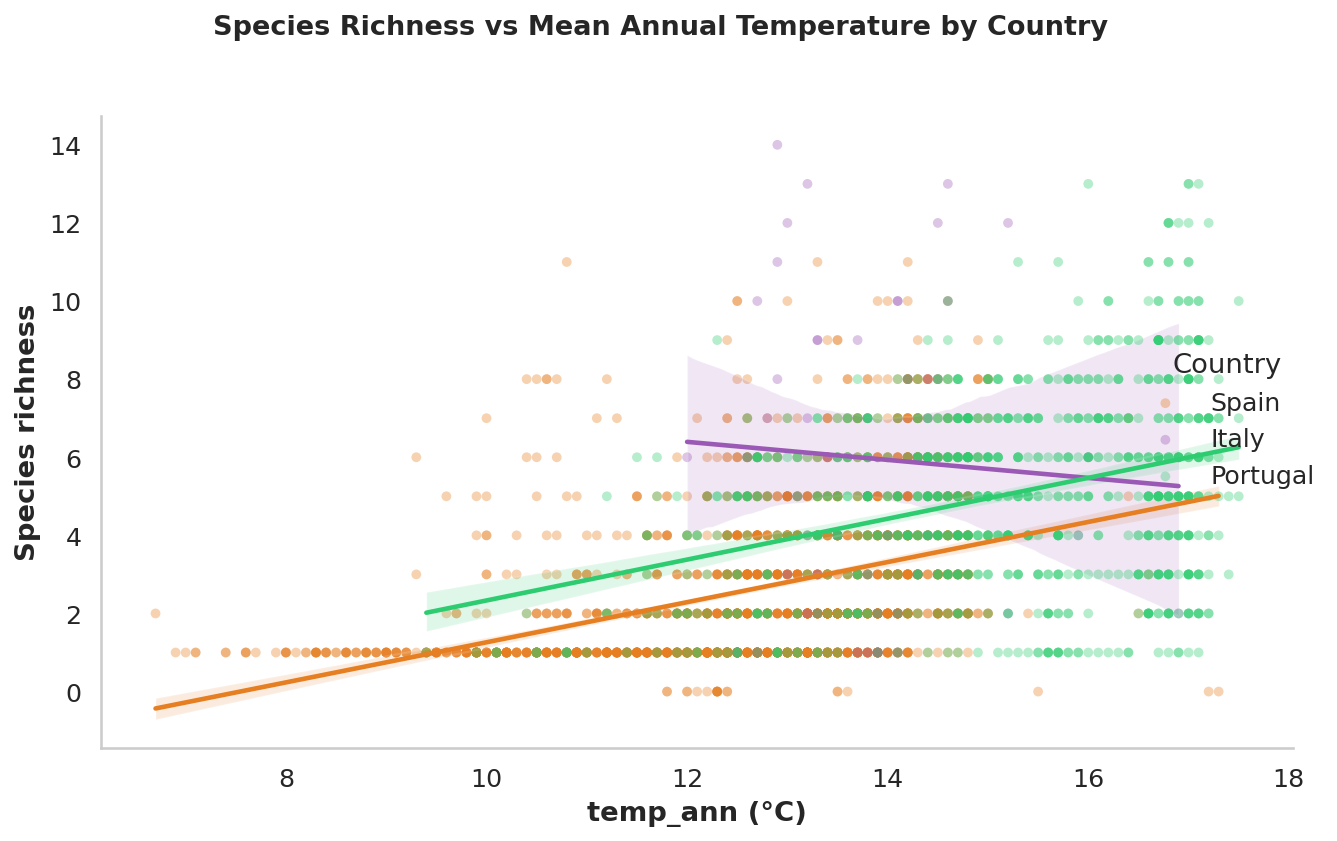

In [15]:
g = sns.lmplot(
    data=df2, x='temp_ann', y='species_richness',
    hue='Country', height=5.5, aspect=1.4,
    palette={'Italy': '#9b59b6', 'Portugal': '#2ecc71', 'Spain': '#e67e22'},
    scatter_kws={'alpha': 0.35, 's': 22, 'edgecolor': 'none'},
    line_kws={'linewidth': 2.2},
    ci=95,
)
g.set_axis_labels("temp_ann (°C)", "Species richness")
g.fig.suptitle("Species Richness vs Mean Annual Temperature by Country",
               fontsize=13, fontweight='bold', y=1.02)
g.ax.grid(False)
plt.tight_layout()
plt.show()

In [16]:
# @title Country-level regression coefficients

rows = []
for country, sub in df2.groupby('Country'):
    slope, intercept, r, p, _ = stats.linregress(sub['temp_ann'], sub['species_richness'])
    rows.append({
        'Country': country, 'n': len(sub),
        'slope': round(slope, 3),
        'intercept': round(intercept, 2),
        'r': round(r, 3),
        'p-value': p,
    })
pd.DataFrame(rows).set_index('Country')

,n,slope,intercept,r,p-value
Country,,,,,
Italy,51,-0.231,9.17,-0.056,6.943354e-01
Portugal,866,0.523,-2.90,0.337,1.721291e-24
Spain,1905,0.514,-3.87,0.407,7.699172e-77


The regression lines reveal that the relationship between mean annual temperature and species richness is **not the same across countries**:

- **Spain** shows a clear positive relationship, where warmer sites tend to host more species.
- **Portugal** shows a much flatter (or slightly negative) relationship, indicating that temperature alone is a weaker predictor of richness there.
- **Italy** has very few sites, so its slope is highly uncertain (wide confidence band).

This suggests that country-specific factors (catchment characteristics, sampling design, biogeography) modulate how temperature relates to species richness, and a single pooled regression would mask these differences.